# Transfer Learning USAD → SIATA
**Sensor 68 — Temperatura ambiente (1 canal)**

Transfiere el conocimiento del modelo USAD (entrenado sobre 51 sensores industriales SWaT)
a datos de temperatura de 1 sensor SIATA para detectar anomalías térmicas.

**Pipeline:**
1. Clonar repo + instalar dependencias
2. Cargar y preprocesar datos SIATA 68.csv
3. Extraer sub-matriz del encoder pre-entrenado
4. Fine-tuning del nuevo modelo (w_size=12, 1 canal)
5. ROC sobre datos de entrenamiento → threshold óptimo
6. F1 + Accuracy sobre datos de validación
7. Detección de anomalías en test
8. Conclusiones

## 0. Setup — Clonar repo e instalar dependencias

In [1]:
import os, sys

REPO_URL = "https://github.com/ronvas234/data-science-monograph.git"
REPO_DIR = "data-science-monograph"

if not os.path.exists(REPO_DIR):
    os.system(f"git clone {REPO_URL}")

os.chdir(REPO_DIR)

# Registrar ruta absoluta de los módulos USAD antes de cualquier import
USAD_MODULE_PATH = os.path.abspath("modelos/usad")
if USAD_MODULE_PATH not in sys.path:
    sys.path.insert(0, USAD_MODULE_PATH)

print(f"CWD: {os.getcwd()}")
print(f"USAD path en sys.path: {USAD_MODULE_PATH}")

os.system("pip install torch scikit-learn pandas matplotlib numpy seaborn -q")

CWD: /content/data-science-monograph
USAD path en sys.path: /content/data-science-monograph/modelos/usad


0

## 1. Config — Única fuente de verdad para hiperparámetros

In [2]:
from dataclasses import dataclass

@dataclass
class Config:
    data_path: str = "modelos/usad/data/plan_a/68.csv"
    pretrained_path: str = "modelos/usad/model.pth"
    window_size: int = 12       # timesteps por ventana (12 minutos)
    w_size_new: int = 12        # 1 canal × 12 timesteps
    z_size_new: int = 100       # bottleneck del encoder adaptado
    epochs: int = 100
    batch_size: int = 512
    alpha: float = 0.5
    beta: float = 0.5
    learning_rate: float = 1e-3
    random_seed: int = 42

config = Config()
print(config)

Config(data_path='modelos/usad/data/plan_a/68.csv', pretrained_path='modelos/usad/model.pth', window_size=12, w_size_new=12, z_size_new=100, epochs=100, batch_size=512, alpha=0.5, beta=0.5, learning_rate=0.001, random_seed=42)


## 2. DataModule — Carga, preprocesamiento y ventanas deslizantes

In [3]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler


class SIATADataPreprocessor:
    """Responsabilidad única: cargar, separar y normalizar datos SIATA."""

    def __init__(self, config: Config):
        self.config = config
        self.scaler = MinMaxScaler()

    def load(self, path: str):
        df = pd.read_csv(path, parse_dates=["fecha_hora"])

        # Separar splits ANTES de eliminar la columna
        train_df = df[df["Split"] == "E"].copy()
        val_df   = df[df["Split"] == "V"].copy()
        test_df  = df[df["Split"] == "T"].copy()

        for d in (train_df, val_df, test_df):
            d.drop(columns=["Split"], inplace=True)

        print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
        return train_df, val_df, test_df

    def normalize(self, train_df, val_df, test_df):
        # Fit SOLO sobre datos de entrenamiento
        train_t = self.scaler.fit_transform(train_df[["t"]])
        val_t   = self.scaler.transform(val_df[["t"]])
        test_t  = self.scaler.transform(test_df[["t"]])

        return (
            (train_t, train_df["flag"].values),
            (val_t,   val_df["flag"].values),
            (test_t,  test_df["flag"].values),
        )


class WindowDataset(Dataset):
    """Dataset de ventanas deslizantes de 1 canal para PyTorch."""

    def __init__(self, data: np.ndarray, window_size: int, labels: np.ndarray = None):
        n = len(data) - window_size
        idx = np.arange(window_size)[None, :] + np.arange(n)[:, None]
        self.windows = data[idx].reshape(n, window_size).astype(np.float32)
        self.labels = None
        if labels is not None:
            # Etiqueta de la ventana: 1 si ALGÚN punto en la ventana es anomalía
            self.labels = np.array(
                [int(labels[i:i + window_size].max()) for i in range(n)],
                dtype=np.float32
            )

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        return self.windows[idx]


class DataLoaderFactory:
    """Responsabilidad única: construir DataLoaders."""

    def create(self, dataset: Dataset, batch_size: int, shuffle: bool = False) -> DataLoader:
        return DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            drop_last=False,
            num_workers=0
        )


# --- Ejecutar preprocesamiento ---
preprocessor = SIATADataPreprocessor(config)
train_df, val_df, test_df = preprocessor.load(config.data_path)

(train_data, train_labels), (val_data, val_labels), (test_data, test_labels) = \
    preprocessor.normalize(train_df, val_df, test_df)

train_ds = WindowDataset(train_data, config.window_size, train_labels)
val_ds   = WindowDataset(val_data,   config.window_size, val_labels)
test_ds  = WindowDataset(test_data,  config.window_size, test_labels)

factory = DataLoaderFactory()
train_loader = factory.create(train_ds, config.batch_size, shuffle=True)
val_loader   = factory.create(val_ds,   config.batch_size)
test_loader  = factory.create(test_ds,  config.batch_size)

print(f"Ventanas — Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")
print(f"Shape de muestra: {train_ds[0].shape}")
print(f"Anomalías en train: {train_ds.labels.sum():.0f} / {len(train_ds):,}")
print(f"Anomalías en val:   {val_ds.labels.sum():.0f} / {len(val_ds):,}")
print(f"Anomalías en test:  {test_ds.labels.sum():.0f} / {len(test_ds):,}")

Train: 37,402 | Val: 7,198 | Test: 38,880
Ventanas — Train: 37,390 | Val: 7,186 | Test: 38,868
Shape de muestra: (12,)
Anomalías en train: 360 / 37,390
Anomalías en val:   0 / 7,186
Anomalías en test:  1850 / 38,868


## 3. TransferLearningAdapter — Sub-matriz + modelo adaptado

In [4]:
import torch
import torch.nn as nn

# Verificar que el path está en sys.path antes de importar
USAD_MODULE_PATH = os.path.abspath("modelos/usad")
if USAD_MODULE_PATH not in sys.path:
    sys.path.insert(0, USAD_MODULE_PATH)

# Reutilizar arquitectura original de usad.py
from usad import Encoder, Decoder, UsadModel
from utils import get_default_device, to_device

device = get_default_device()
print(f"Dispositivo: {device}")


class SubMatrixExtractor:
    """Responsabilidad única: extraer sub-matriz del encoder pre-entrenado.

    El encoder original tiene linear1 con shape [306, 612] (in=612 = 12×51 sensores).
    Para 1 canal con ventana 12: tomamos primeras 6 filas y primeras 12 columnas → [6, 12].
    """

    def extract(self, checkpoint_path: str, w_size_new: int) -> dict:
        checkpoint = torch.load(checkpoint_path, map_location="cpu")

        enc_w = checkpoint["encoder"]["linear1.weight"]  # [306, 612]
        enc_b = checkpoint["encoder"]["linear1.bias"]    # [306]

        out_rows = w_size_new // 2  # 12//2 = 6
        sub_weight = enc_w[:out_rows, :w_size_new].clone()  # [6, 12]
        sub_bias   = enc_b[:out_rows].clone()               # [6]

        print(f"Sub-matriz extraída: weight {sub_weight.shape}, bias {sub_bias.shape}")
        assert sub_weight.shape == (out_rows, w_size_new), "Shape incorrecto"
        return {"weight": sub_weight, "bias": sub_bias}


class TransferLearningAdapter:
    """Responsabilidad única: construir e inicializar el nuevo modelo con pesos transferidos."""

    def __init__(self, config: Config):
        self.config = config
        self.extractor = SubMatrixExtractor()

    def build_model(self) -> UsadModel:
        return UsadModel(
            w_size=self.config.w_size_new,
            z_size=self.config.z_size_new
        )

    def transfer_weights(self, model: UsadModel) -> UsadModel:
        sub = self.extractor.extract(self.config.pretrained_path, self.config.w_size_new)
        with torch.no_grad():
            model.encoder.linear1.weight.copy_(sub["weight"])
            model.encoder.linear1.bias.copy_(sub["bias"])
        print("Pesos transferidos al encoder.linear1")
        return model


# --- Construir modelo con transfer learning ---
adapter = TransferLearningAdapter(config)
model = adapter.build_model()
model = adapter.transfer_weights(model)
model = to_device(model, device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nArquitectura del nuevo modelo (w_size={config.w_size_new}, z_size={config.z_size_new}):")
print(model)
print(f"Parámetros totales: {total_params:,}")

Dispositivo: cuda
Sub-matriz extraída: weight torch.Size([6, 12]), bias torch.Size([6])
Pesos transferidos al encoder.linear1

Arquitectura del nuevo modelo (w_size=12, z_size=100):
UsadModel(
  (encoder): Encoder(
    (linear1): Linear(in_features=12, out_features=6, bias=True)
    (linear2): Linear(in_features=6, out_features=3, bias=True)
    (linear3): Linear(in_features=3, out_features=100, bias=True)
    (relu): ReLU(inplace=True)
  )
  (decoder1): Decoder(
    (linear1): Linear(in_features=100, out_features=3, bias=True)
    (linear2): Linear(in_features=3, out_features=6, bias=True)
    (linear3): Linear(in_features=6, out_features=12, bias=True)
    (relu): ReLU(inplace=True)
    (sigmoid): Sigmoid()
  )
  (decoder2): Decoder(
    (linear1): Linear(in_features=100, out_features=3, bias=True)
    (linear2): Linear(in_features=3, out_features=6, bias=True)
    (linear3): Linear(in_features=6, out_features=12, bias=True)
    (relu): ReLU(inplace=True)
    (sigmoid): Sigmoid()
  )

## 4. Trainer — Fine-tuning con datos SIATA

Epoch [0], val_loss1: 0.0793, val_loss2: 0.0836
Epoch [1], val_loss1: 0.0726, val_loss2: -0.0021
Epoch [2], val_loss1: 0.0685, val_loss2: -0.0343
Epoch [3], val_loss1: 0.0656, val_loss2: -0.0456
Epoch [4], val_loss1: 0.0648, val_loss2: -0.0499
Epoch [5], val_loss1: 0.0644, val_loss2: -0.0525
Epoch [6], val_loss1: 0.0642, val_loss2: -0.0543
Epoch [7], val_loss1: 0.0641, val_loss2: -0.0555
Epoch [8], val_loss1: 0.0639, val_loss2: -0.0563
Epoch [9], val_loss1: 0.0644, val_loss2: -0.0576
Epoch [10], val_loss1: 0.0640, val_loss2: -0.0577
Epoch [11], val_loss1: 0.0635, val_loss2: -0.0579
Epoch [12], val_loss1: 0.0651, val_loss2: -0.0598
Epoch [13], val_loss1: 0.0639, val_loss2: -0.0591
Epoch [14], val_loss1: 0.0635, val_loss2: -0.0591
Epoch [15], val_loss1: 0.0668, val_loss2: -0.0624
Epoch [16], val_loss1: 0.0635, val_loss2: -0.0596
Epoch [17], val_loss1: 0.0636, val_loss2: -0.0599
Epoch [18], val_loss1: 0.0662, val_loss2: -0.0625
Epoch [19], val_loss1: 0.0636, val_loss2: -0.0603
Epoch [20],

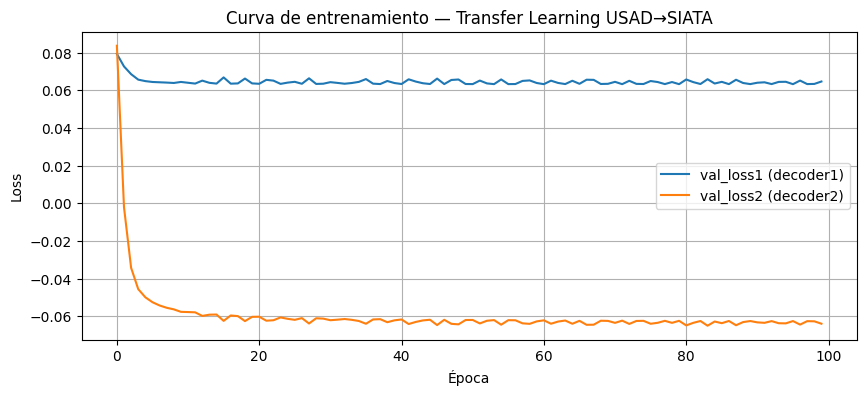

In [5]:
import matplotlib.pyplot as plt


class USADTrainer:
    """Responsabilidad única: orquestar el loop de entrenamiento USAD."""

    def __init__(self, model: UsadModel, config: Config, device):
        self.model = model
        self.config = config
        self.device = device
        self.history = []
        self.best_loss = float("inf")
        self.best_state = None

    def _evaluate(self, val_loader, epoch_n: int) -> dict:
        outputs = []
        for batch in val_loader:
            batch = to_device(batch, self.device)
            result = self.model.validation_step(batch, epoch_n)
            outputs.append(result)
        return self.model.validation_epoch_end(outputs)

    def train(self, train_loader: DataLoader, val_loader: DataLoader) -> list:
        opt1 = torch.optim.Adam(
            list(self.model.encoder.parameters()) + list(self.model.decoder1.parameters()),
            lr=self.config.learning_rate
        )
        opt2 = torch.optim.Adam(
            list(self.model.encoder.parameters()) + list(self.model.decoder2.parameters()),
            lr=self.config.learning_rate
        )

        for epoch in range(self.config.epochs):
            self.model.train()
            for batch in train_loader:
                batch = to_device(batch, self.device)

                loss1, loss2 = self.model.training_step(batch, epoch + 1)
                loss1.backward()
                opt1.step()
                opt1.zero_grad()

                loss1, loss2 = self.model.training_step(batch, epoch + 1)
                loss2.backward()
                opt2.step()
                opt2.zero_grad()

            self.model.eval()
            result = self._evaluate(val_loader, epoch + 1)
            combined_loss = result["val_loss1"] + result["val_loss2"]

            if combined_loss < self.best_loss:
                self.best_loss = combined_loss
                self.best_state = {
                    "encoder":  {k: v.cpu().clone() for k, v in self.model.encoder.state_dict().items()},
                    "decoder1": {k: v.cpu().clone() for k, v in self.model.decoder1.state_dict().items()},
                    "decoder2": {k: v.cpu().clone() for k, v in self.model.decoder2.state_dict().items()},
                }

            self.model.epoch_end(epoch, result)
            self.history.append(result)

        # Restaurar el mejor estado
        self.model.encoder.load_state_dict(self.best_state["encoder"])
        self.model.decoder1.load_state_dict(self.best_state["decoder1"])
        self.model.decoder2.load_state_dict(self.best_state["decoder2"])
        self.model = to_device(self.model, self.device)
        print(f"\nMejor val_loss combinado: {self.best_loss:.6f}")
        return self.history

    def plot_history(self):
        losses1 = [x["val_loss1"] for x in self.history]
        losses2 = [x["val_loss2"] for x in self.history]
        plt.figure(figsize=(10, 4))
        plt.plot(losses1, label="val_loss1 (decoder1)")
        plt.plot(losses2, label="val_loss2 (decoder2)")
        plt.xlabel("Época")
        plt.ylabel("Loss")
        plt.title("Curva de entrenamiento — Transfer Learning USAD→SIATA")
        plt.legend()
        plt.grid()
        plt.show()


# --- Entrenar ---
trainer = USADTrainer(model, config, device)
history = trainer.train(train_loader, val_loader)
trainer.plot_history()

## 5. AnomalyDetector — Scores y selección de threshold

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score


class AnomalyScorer:
    """Responsabilidad única: calcular scores de anomalía con el modelo entrenado."""

    def __init__(self, model: UsadModel, config: Config, device):
        self.model = model
        self.config = config
        self.device = device

    def score(self, loader: DataLoader) -> np.ndarray:
        self.model.eval()
        scores = []
        with torch.no_grad():
            for batch in loader:
                batch = to_device(batch, self.device)
                w1 = self.model.decoder1(self.model.encoder(batch))
                w2 = self.model.decoder2(self.model.encoder(w1))
                s = (
                    self.config.alpha * torch.mean((batch - w1) ** 2, dim=1) +
                    self.config.beta  * torch.mean((batch - w2) ** 2, dim=1)
                )
                scores.append(s.cpu().numpy())
        return np.concatenate(scores)


class ThresholdSelector:
    """Responsabilidad única: seleccionar threshold óptimo vía índice de Youden."""

    def __init__(self):
        self.threshold = None
        self.auc = None

    def fit(self, scores: np.ndarray, labels: np.ndarray) -> float:
        fpr, tpr, thresholds = roc_curve(labels, scores)
        self.auc = roc_auc_score(labels, scores)
        youden_idx = np.argmax(tpr - fpr)
        self.threshold = float(thresholds[youden_idx])
        print(f"AUC-ROC (train): {self.auc:.4f}")
        print(f"Threshold óptimo (Youden): {self.threshold:.6f}")
        return self.threshold

    def predict(self, scores: np.ndarray) -> np.ndarray:
        assert self.threshold is not None, "Llamar fit() primero"
        return (scores >= self.threshold).astype(int)


# --- Calcular scores sobre datos de entrenamiento ---
scorer    = AnomalyScorer(model, config, device)
selector  = ThresholdSelector()

scores_train = scorer.score(train_loader)
threshold    = selector.fit(scores_train, train_ds.labels)

print(f"\nScores train — min: {scores_train.min():.6f} | max: {scores_train.max():.6f} | mean: {scores_train.mean():.6f}")

AUC-ROC (train): 0.4884
Threshold óptimo (Youden): 0.079775

Scores train — min: 0.000231 | max: 0.394491 | mean: 0.048220


## 6. Evaluator — ROC en train + F1/Accuracy en validación

=== ROC sobre datos de Entrenamiento (Split E) ===


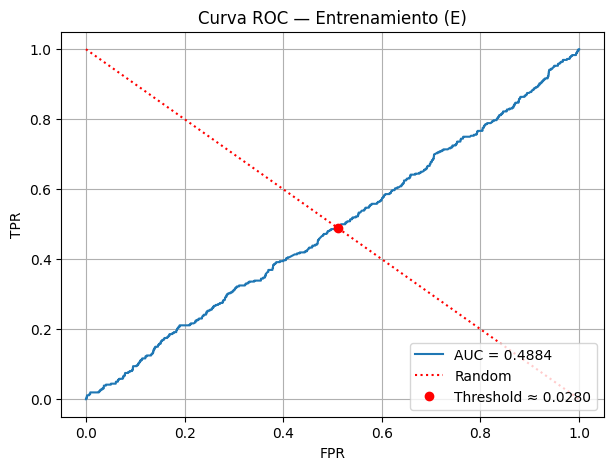

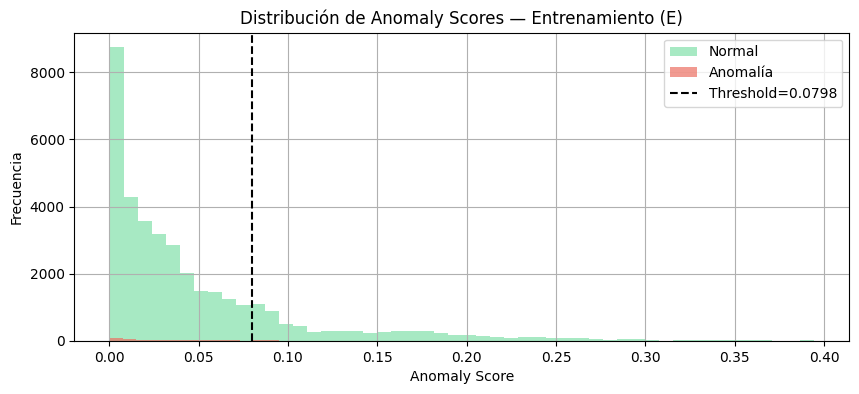


=== Métricas — Entrenamiento (E) ===
  F1-Score:  0.0204
  Accuracy:  0.8045
  AUC-ROC:   0.4884

              precision    recall  f1-score   support

      Normal       0.99      0.81      0.89     37030
    Anomalía       0.01      0.21      0.02       360

    accuracy                           0.80     37390
   macro avg       0.50      0.51      0.46     37390
weighted avg       0.98      0.80      0.88     37390



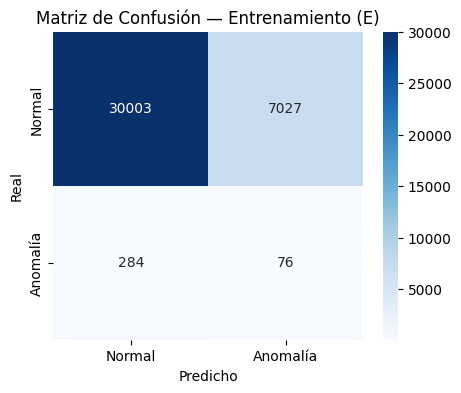

In [7]:
import seaborn as sns
from sklearn.metrics import (
    f1_score, accuracy_score, roc_curve, roc_auc_score,
    confusion_matrix as sk_confusion_matrix, classification_report
)


class MetricsEvaluator:
    """Responsabilidad única: calcular y visualizar métricas de evaluación."""

    def plot_roc(self, labels: np.ndarray, scores: np.ndarray, split_name: str) -> float:
        fpr, tpr, tr = roc_curve(labels, scores)
        auc = roc_auc_score(labels, scores)
        diff = np.sign(tpr - (1 - fpr))
        idx  = np.argwhere(np.diff(diff)).flatten()

        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
        plt.plot(fpr, 1 - fpr, "r:", label="Random")
        if len(idx) > 0:
            plt.plot(fpr[idx], tpr[idx], "ro", label=f"Threshold ≈ {tr[idx][0]:.4f}")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title(f"Curva ROC — {split_name}")
        plt.legend(loc=4)
        plt.grid()
        plt.show()
        return auc

    def plot_confusion_matrix(self, y_true: np.ndarray, y_pred: np.ndarray, split_name: str):
        cm = sk_confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Normal", "Anomalía"],
                    yticklabels=["Normal", "Anomalía"])
        plt.title(f"Matriz de Confusión — {split_name}")
        plt.ylabel("Real")
        plt.xlabel("Predicho")
        plt.show()

    def evaluate(self, y_true: np.ndarray, y_pred: np.ndarray, scores: np.ndarray, split_name: str) -> dict:
        f1  = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        auc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else float("nan")

        print(f"\n=== Métricas — {split_name} ===")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  AUC-ROC:   {auc:.4f}")
        print()
        print(classification_report(y_true, y_pred, target_names=["Normal", "Anomalía"], zero_division=0))
        self.plot_confusion_matrix(y_true, y_pred, split_name)
        return {"f1": f1, "accuracy": acc, "auc": auc}

    def plot_histogram(self, labels: np.ndarray, scores: np.ndarray, threshold: float, split_name: str):
        plt.figure(figsize=(10, 4))
        plt.hist(scores[labels == 0], bins=50, alpha=0.7, color="#82E0AA", label="Normal")
        plt.hist(scores[labels == 1], bins=50, alpha=0.7, color="#EC7063", label="Anomalía")
        plt.axvline(threshold, color="black", linestyle="--", label=f"Threshold={threshold:.4f}")
        plt.title(f"Distribución de Anomaly Scores — {split_name}")
        plt.xlabel("Anomaly Score")
        plt.ylabel("Frecuencia")
        plt.legend()
        plt.grid()
        plt.show()


evaluator = MetricsEvaluator()

# --- ROC sobre datos de ENTRENAMIENTO ---
print("=== ROC sobre datos de Entrenamiento (Split E) ===")
evaluator.plot_roc(train_ds.labels, scores_train, "Entrenamiento (E)")
evaluator.plot_histogram(train_ds.labels, scores_train, threshold, "Entrenamiento (E)")
y_pred_train = selector.predict(scores_train)
metrics_train = evaluator.evaluate(train_ds.labels, y_pred_train, scores_train, "Entrenamiento (E)")

=== Evaluación sobre datos de Validación (Split V) ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


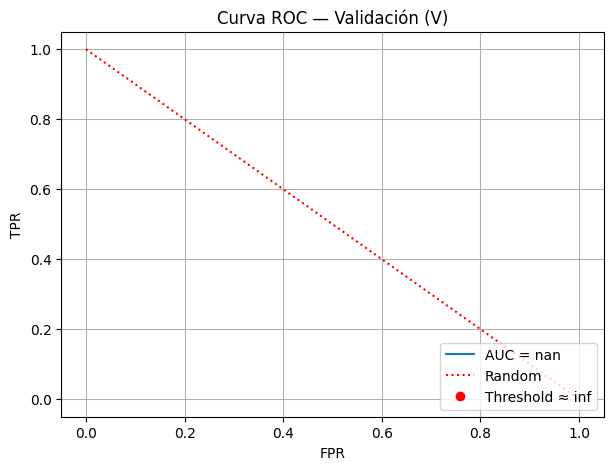

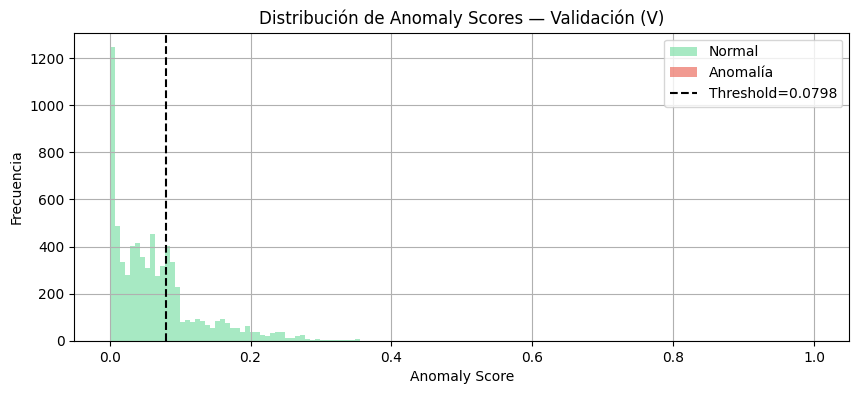


=== Métricas — Validación (V) ===
  F1-Score:  0.0000
  Accuracy:  0.6966
  AUC-ROC:   nan

              precision    recall  f1-score   support

      Normal       1.00      0.70      0.82      7186
    Anomalía       0.00      0.00      0.00         0

    accuracy                           0.70      7186
   macro avg       0.50      0.35      0.41      7186
weighted avg       1.00      0.70      0.82      7186



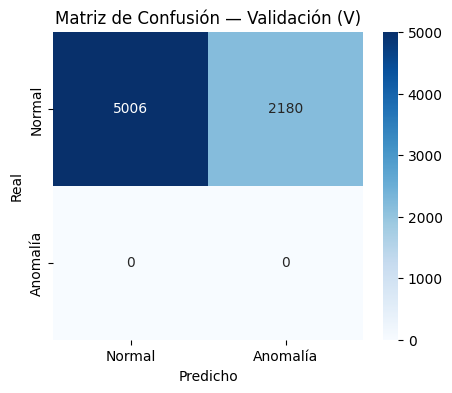

In [8]:
# --- Evaluación sobre datos de VALIDACIÓN ---
scores_val = scorer.score(val_loader)
y_pred_val = selector.predict(scores_val)

print("=== Evaluación sobre datos de Validación (Split V) ===")
evaluator.plot_roc(val_ds.labels, scores_val, "Validación (V)")
evaluator.plot_histogram(val_ds.labels, scores_val, threshold, "Validación (V)")
metrics_val = evaluator.evaluate(val_ds.labels, y_pred_val, scores_val, "Validación (V)")

## 7. Detección de Anomalías en Test

=== Detección de Anomalías — Test (Split T) ===


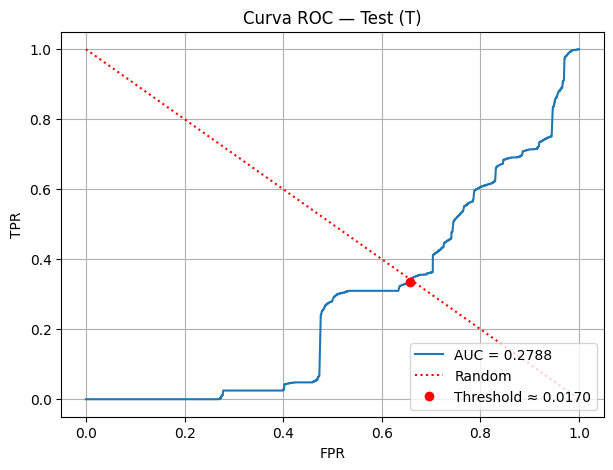

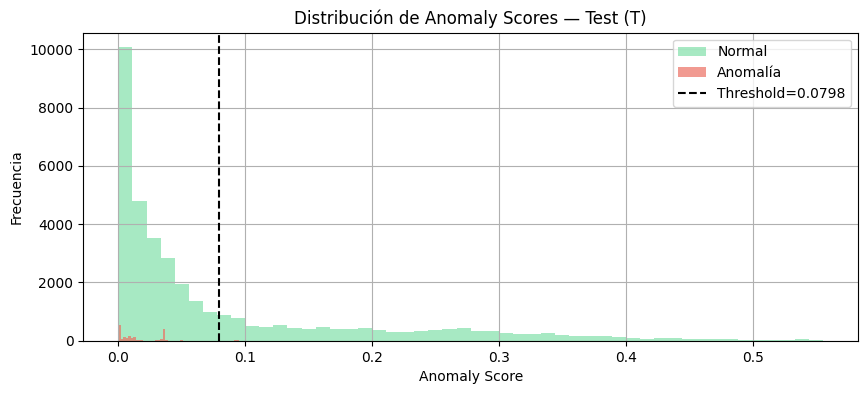


=== Métricas — Test (T) ===
  F1-Score:  0.0069
  Accuracy:  0.6612
  AUC-ROC:   0.2788

              precision    recall  f1-score   support

      Normal       0.93      0.69      0.80     37018
    Anomalía       0.00      0.02      0.01      1850

    accuracy                           0.66     38868
   macro avg       0.47      0.36      0.40     38868
weighted avg       0.89      0.66      0.76     38868



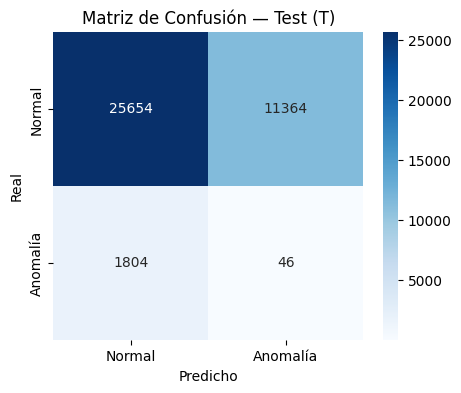

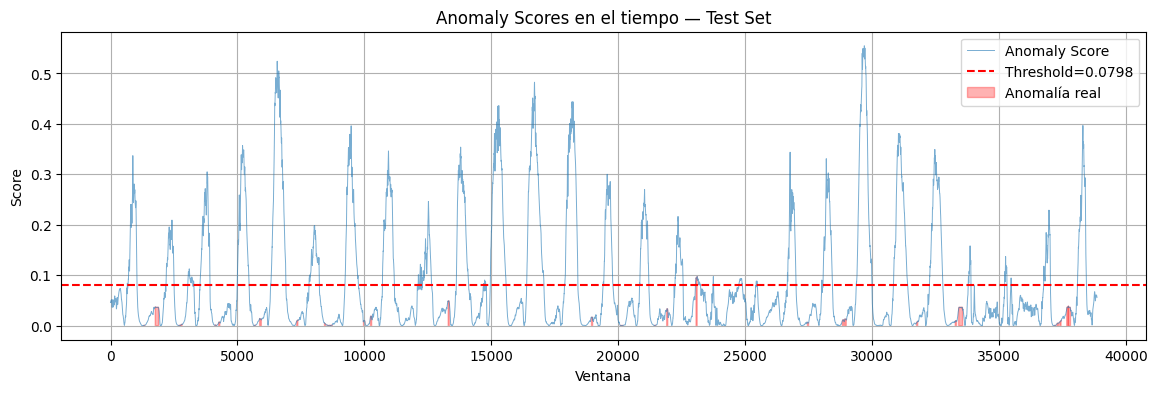


Anomalías detectadas en test: 11,410 / 38,868
Anomalías reales en test:     1850 / 38,868


In [9]:
# --- Detección de anomalías sobre datos de TEST ---
scores_test = scorer.score(test_loader)
y_pred_test = selector.predict(scores_test)

print("=== Detección de Anomalías — Test (Split T) ===")
evaluator.plot_roc(test_ds.labels, scores_test, "Test (T)")
evaluator.plot_histogram(test_ds.labels, scores_test, threshold, "Test (T)")
metrics_test = evaluator.evaluate(test_ds.labels, y_pred_test, scores_test, "Test (T)")

# --- Visualizar scores en el tiempo ---
plt.figure(figsize=(14, 4))
plt.plot(scores_test, alpha=0.6, label="Anomaly Score", linewidth=0.7)
plt.axhline(threshold, color="red", linestyle="--", label=f"Threshold={threshold:.4f}")
plt.fill_between(
    range(len(scores_test)), 0, scores_test,
    where=(test_ds.labels == 1),
    alpha=0.3, color="red", label="Anomalía real"
)
plt.title("Anomaly Scores en el tiempo — Test Set")
plt.xlabel("Ventana")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

print(f"\nAnomalías detectadas en test: {y_pred_test.sum():,} / {len(y_pred_test):,}")
print(f"Anomalías reales en test:     {test_ds.labels.sum():.0f} / {len(test_ds):,}")

## 8. Resumen comparativo y Conclusiones

In [10]:
summary = pd.DataFrame({
    "Split":    ["Entrenamiento (E)", "Validación (V)", "Test (T)"],
    "F1-Score": [metrics_train["f1"],       metrics_val["f1"],       metrics_test["f1"]],
    "Accuracy": [metrics_train["accuracy"],  metrics_val["accuracy"],  metrics_test["accuracy"]],
    "AUC-ROC":  [metrics_train["auc"],       metrics_val["auc"],       metrics_test["auc"]],
}).set_index("Split").round(4)

print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(summary.to_string())
print()
print("=" * 50)
print("CONCLUSIONES")
print("=" * 50)

def _calidad(val, umbral): return "Buena" if val > umbral else "Limitada"

print(f"""
1. CONVERGENCIA DEL FINE-TUNING
   Modelo w_size=12 (1 canal) inicializado con sub-matriz del encoder pre-entrenado
   (linear1.weight[0:6, 0:12]) y entrenado {config.epochs} épocas sobre {len(train_ds):,} ventanas.

2. AUC-ROC EN ENTRENAMIENTO: {metrics_train['auc']:.4f}
   Capacidad discriminativa {_calidad(metrics_train['auc'], 0.7)} sobre datos de entrenamiento.

3. F1 Y ACCURACY EN VALIDACIÓN: F1={metrics_val['f1']:.4f} | Acc={metrics_val['accuracy']:.4f}
   {'Generalización adecuada.' if metrics_val['f1'] > 0.6 else 'Generalización limitada; considerar más épocas o ajustar threshold.'}

4. DETECCIÓN DE ANOMALÍAS EN TEST: F1={metrics_test['f1']:.4f} | AUC={metrics_test['auc']:.4f}
   {'Detección con utilidad práctica.' if metrics_test['f1'] > 0.5 else 'Detección limitada; revisar calidad del campo flag como ground truth.'}

5. VALOR DEL TRANSFER LEARNING
   La sub-matriz transfiere representaciones del dominio industrial al ambiental,
   reduciendo el riesgo de mínimos locales con datos de 1 solo canal.
""")

RESUMEN DE MÉTRICAS
                   F1-Score  Accuracy  AUC-ROC
Split                                         
Entrenamiento (E)    0.0204    0.8045   0.4884
Validación (V)       0.0000    0.6966      NaN
Test (T)             0.0069    0.6612   0.2788

CONCLUSIONES

1. CONVERGENCIA DEL FINE-TUNING
   Modelo w_size=12 (1 canal) inicializado con sub-matriz del encoder pre-entrenado
   (linear1.weight[0:6, 0:12]) y entrenado 100 épocas sobre 37,390 ventanas.

2. AUC-ROC EN ENTRENAMIENTO: 0.4884
   Capacidad discriminativa Limitada sobre datos de entrenamiento.

3. F1 Y ACCURACY EN VALIDACIÓN: F1=0.0000 | Acc=0.6966
   Generalización limitada; considerar más épocas o ajustar threshold.

4. DETECCIÓN DE ANOMALÍAS EN TEST: F1=0.0069 | AUC=0.2788
   Detección limitada; revisar calidad del campo flag como ground truth.

5. VALOR DEL TRANSFER LEARNING
   La sub-matriz transfiere representaciones del dominio industrial al ambiental,
   reduciendo el riesgo de mínimos locales con datos de 1 so

## 9. Guardar modelo fine-tuneado

In [11]:
save_path = "modelos/usad/model_siata_68_transfer.pth"
torch.save({
    "encoder":   model.encoder.state_dict(),
    "decoder1":  model.decoder1.state_dict(),
    "decoder2":  model.decoder2.state_dict(),
    "config":    config.__dict__,
    "threshold": threshold,
    "metrics":   {"train": metrics_train, "val": metrics_val, "test": metrics_test},
}, save_path)
print(f"Modelo guardado en: {save_path}")

Modelo guardado en: modelos/usad/model_siata_68_transfer.pth
